<div style="display: flex; gap: 10px;">
  <img src="../images/HOOPS_AI.jpg" style="width: 20%;">
   

In [1]:
import hoops_ai
import os
import sys

license_key = os.environ.get("HOOPS_AI_LICENSE")
if not license_key:
    sys.exit("HOOPS_AI_LICENSE environment variable is required.")

hoops_ai.set_license(license_key, validate=True)

------------------------------------------------------------
HOOPS AI
------------------------------------------------------------
  Platform      : Windows 11
  Architecture  : AMD64
  Python        : 3.9.21
------------------------------------------------------------
  Core          : hoops-ai             1.0.0  (build: 39b99a8 2026-03-23T19:25:21Z)
  CAD Access    : hoops-exchange       26.2.0  (build: 1e11169 2026-03-23T19:16:49Z)
  Conversion    : hoops-converter      26.1.0  (build: 39b99a8 2026-03-23T19:15:42Z)
  Insights      : hoops-web-viewer     26.1.0  (build: 25137b2 2026-03-23T19:20:34Z)
------------------------------------------------------------
[OK] HOOPS AI License: Valid


In [2]:
import pathlib, sys
sys.path.insert(0, str( pathlib.Path.cwd()))
import importlib
from scripts import helper_tutorials  
importlib.reload(helper_tutorials)  # Forces reload of the latest version

<module 'scripts.helper_tutorials' from 'C:\\Users\\LuisSalazar.LY-LS-LEGION\\Documents\\repos\\HOOPS-AI-tutorials\\notebooks\\scripts\\helper_tutorials.py'>

# HOOPS AI: Using a Pre-trained Model

In this tutorial, we use a pre-trained model to detect manufacturing features. The model was trained with HOOPS AI using the pre-built `GraphNodeClassification` architecture. The dataset contained more than 160,000 CAD files, split as follows:

Train set contains          : 113878 samples (70.12%)
Validation set contains     : 24220 samples (14.91%)
Test set contains           : 24311 samples (14.97%)
Total samples               : 162409

The model reported an IoU (intersection-over-union) score of 98.9% on the test set.

The training data combines synthetic samples describing machining features from the CADSynth dataset and instance-labeled machining-feature samples from the MFInstSeg dataset. Both datasets are public.

<div style="display: flex; gap: 10px;">
  <img src="../images/features_sampling_dataset.png" style="width: 50%;">
  <img src="../images/features_intersection_dataset.png" style="width: 50%;">
</div>

The model was then tested on unseen real-part samples. It was able to detect some features in real cases, showing that beyond the simplified training data, the model learned how to detect the features.

## Dataset Citations

This notebook relies on a model trained with data derived from the following public datasets.

**CADSynth**
Zhang, Shuming (2024). *CADSynth: A Dataset for Machining Feature Recognition in B-rep Models*. V1. Science Data Bank. https://doi.org/10.57760/sciencedb.17011

Dataset page: https://www.scidb.cn/en/detail?dataSetId=931c088fd44f4d3e82891a5180f10d90

**MFInstSeg**
*MFInstSeg: 62,495 solid models in STEP format with instance labels in JSON format*. Baidu AI Studio dataset page. https://aistudio.baidu.com/datasetdetail/211864?lang=en.

Use this dataset page citation when referencing the MFInstSeg data source in these tutorial materials.

In [3]:
from hoops_ai.dataset import DatasetExplorer

flow_name = "cadsynth10k"
flow_root_dir = pathlib.Path.cwd().parent.joinpath("packages", "flows", flow_name)

parquet_file_path        = str(flow_root_dir.joinpath(f"{flow_name}.infoset"))
merged_store_path     = str(flow_root_dir.joinpath(f"{flow_name}.dataset"))
parquet_file_attribs  = str(flow_root_dir.joinpath(f"{flow_name}.attribset"))

explorer = DatasetExplorer(merged_store_path=merged_store_path, parquet_file_path=parquet_file_path, parquet_file_attribs=parquet_file_attribs)
#explorer.print_table_of_contents()

INFO:To route to workers diagnostics web server please install jupyter-server-proxy: python -m pip install jupyter-server-proxy
INFO:State start
C:\Users\LuisSalazar.LY-LS-LEGION\Miniconda3\envs\hoops_ai_cpu\lib\contextlib.py:126: UserWarning: Creating scratch directories is taking a surprisingly long time. (1.24s) This is often due to running workers on a network file system. Consider specifying a local-directory to point workers to write scratch data to a local disk.
  next(self.gen)
INFO:  Scheduler at:     tcp://127.0.0.1:56336
INFO:  dashboard at:  http://127.0.0.1:56335/status
INFO:Registering Worker plugin shuffle
INFO:        Start Nanny at: 'tcp://127.0.0.1:56339'
INFO:Register worker <WorkerState 'tcp://127.0.0.1:63182', name: 0, status: init, memory: 0, processing: 0>
INFO:Starting worker compute stream, tcp://127.0.0.1:63182
INFO:Starting established connection to tcp://127.0.0.1:63184
INFO:Receive client connection: Client-39027f55-2856-11f1-a804-f4289de57fc2
INFO:Starting

[DatasetExplorer] Default local cluster started: <Client: 'tcp://127.0.0.1:56336' processes=1 threads=16, memory=7.45 GiB>


Processing file info:   0%|          | 0/9992 [00:00<?, ?it/s]

Variable 'face_labels' found in fallback group 'Labels'.


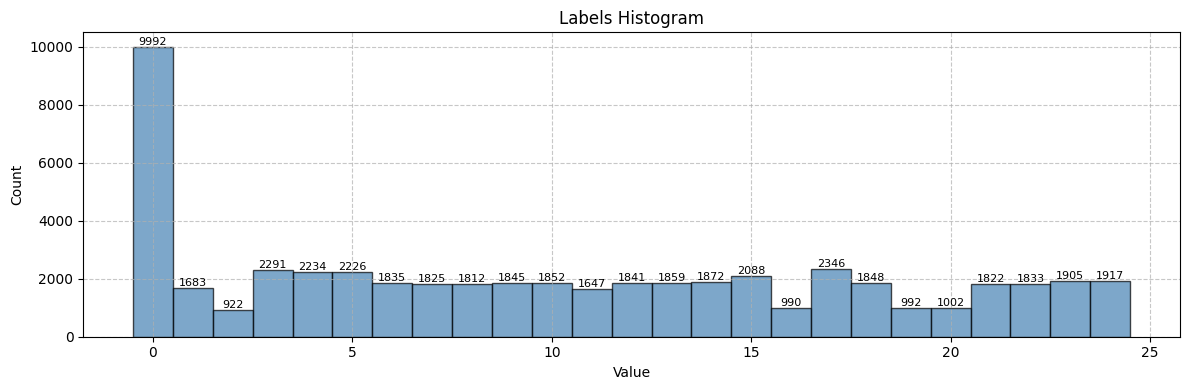

In [4]:
face_dist = explorer.create_distribution(key="face_labels", bins=None, group="faces")
helper_tutorials.print_distribution_info(face_dist, title="Labels")

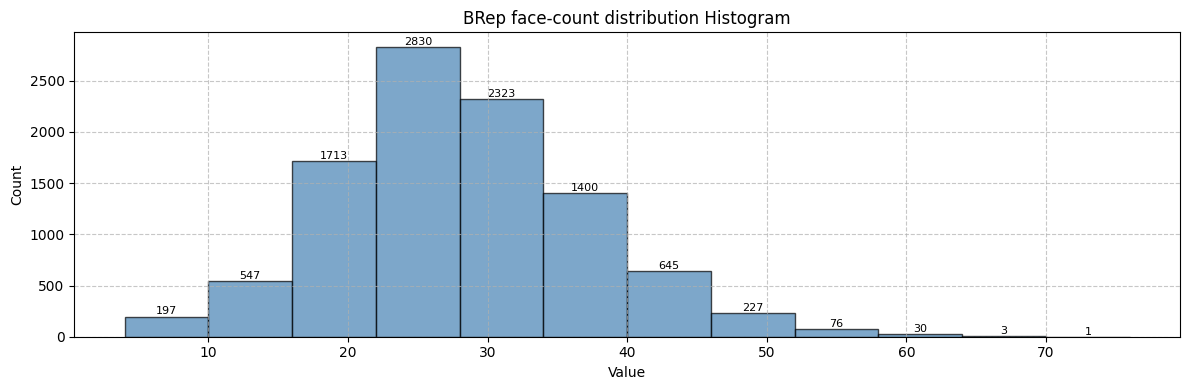

In [5]:
dist = explorer.create_distribution(key="num_nodes", bins=12, group="graph")
helper_tutorials.print_distribution_info(dist, title="BRep face-count distribution")

In [6]:

import pathlib
import json

# Define paths 
demofile_dir  = pathlib.Path.cwd().parent.joinpath("packages", "cadfiles")
output_dir    = pathlib.Path.cwd().joinpath("out")
cad_file_test = str(demofile_dir.joinpath("nist_ftc_06_asme1_rd_sw1802.SLDPRT")) # largest_mftrcad.step
#cad_file_test = str(demofile_dir.joinpath("largest_mftrcad.step")) # 


In [7]:
from hoops_ai.cadaccess import HOOPSLoader
from hoops_ai.insights import CADViewer

# Initialize CAD loader (needed for ML inference later)
loader = HOOPSLoader()

# Create viewer and load CAD file (auto-converts to SCS and displays in sidecar)
viewer = CADViewer(display_mode='sidecar', silent=True, static_folder=output_dir)
viewer.load_cad_file(cad_file_test, auto_convert=True, white_background=True)



True

In [8]:
viewer.show()

# ML prediction 

The `FlowInference` class handles inference with trained models. It provides methods for preprocessing CAD data, making predictions, and post-processing results.

```python
class FlowInference:
    def __init__(self, cad_loader: CADLoader, flowmodel: FlowModel, log_file: str = 'training_errors.log'):
    
    def load_from_checkpoint(self, checkpoint_path: str):
        
    def preprocess(self, file_path: str) -> Dict[str, torch.Tensor]:

    def predict_and_postprocess(self, batch: Dict[str, torch.Tensor]) -> np.ndarray:

```

## Transform the CAD data into machine-learning input data

- Load the trained model from the checkpoint file and instantiate it with the appropriate `FlowModel`
- Initialize `HOOPSLoader` to read the CAD file
- Preprocess the CAD file to encode its data according to the expected ML architecture

In [9]:
from hoops_ai.ml.EXPERIMENTAL import FlowInference
from hoops_ai.ml.EXPERIMENTAL import GraphNodeClassification

trained_model = pathlib.Path.cwd().parent.joinpath("packages","trained_ml_models", "ts3d_162k_mfr.ckpt")

inference_model = FlowInference(cad_loader = loader, flowmodel = GraphNodeClassification(result_dir=output_dir))
inference_model.load_from_checkpoint(trained_model)

Successfully loaded model from checkpoint: C:\Users\LuisSalazar.LY-LS-LEGION\Documents\repos\HOOPS-AI-tutorials\packages\trained_ml_models\ts3d_162k_mfr.ckpt


For the inference test, we use a file from the NIST list.

In [10]:
ml_input = inference_model.preprocess(cad_file_test)    
predictions, probabilities = inference_model.predict_and_postprocess(ml_input)
print(predictions)

[ 0  0 22 22 22 17  0  0 22 22 22 17  0  0 22 22 22 17  0 17  0  0  0  0
  0  0  0  0  0  0  0  0  0  0  0  0  0 17  0  0  0  0  0 17  0  0 17  0
  1  2  2  1  1 17 23 23 17 23 23 17 23 23 17 23 22  0  0 22 22 22 17 22
 22  0 17 17 23 22  2  1  2  1  3 17 16 17 17 17 17 17 17 17 17 16 24 24
 24 24 24 24  0 16  0  0 16 16 16  0 16  0 12 21 21 21 21 21 21 21 12 12
 12 12 12 21 21 21 21 21 21 21 21 21 21 21 21 21 21 12 21 21 21 21 21 21]


# Visualize Predictions on CAD Model

Now that we have predictions for each face, we'll use the **HOOPS AI Insights** module to visualize them on the 3D model.

## Step 1: Create a Color Palette

We use `ColorPalette` to map each manufacturing feature label to a unique color and description. We can optionally reserve specific colors for important features (e.g., red for through holes).


In [11]:
from hoops_ai.insights.utils import ColorPalette

# Define label descriptions
labels_description = {
    0: "no-label", 1: "rectangular_through_slot", 2: "triangular_through_slot", 3: "rectangular_passage",
    4: "triangular_passage", 5: "6sides_passage", 6: "rectangular_through_step", 7: "2sides_through_step",
    8: "slanted_through_step", 9: "rectangular_blind_step", 10: "triangular_blind_step", 
    11: "rectangular_blind_slot", 12: "rectangular_pocket", 13: "triangular_pocket", 14: "6sides_pocket",
    15: "chamfer", 16: "circular through slot", 17: "through hole", 18: "circular blind step",
    19: "horizontal circular end blind slot", 20: "vertical circular end blind slot", 
    21: "circular end pocket", 22: "o-ring", 23: "blind hole", 24: "fillet"
}

# Create color palette with maximally distinct colors (use_distinct_colors=True by default)
color_palette = ColorPalette.from_labels(
    labels_description,
    reserved_colors={
        0: (200, 200, 200),  # Gray for background
    }
)

print(f"Created color palette for {len(color_palette)} labels")
print(f"Sample: Label 17 -> Color {color_palette.get_color(17)}, Description: '{color_palette.get_description(17)}'")
print(f"Sample: Label 22 -> Color {color_palette.get_color(22)}, Description: '{color_palette.get_description(22)}'")
print(f"Sample: Label 23 -> Color {color_palette.get_color(23)}, Description: '{color_palette.get_description(23)}'")
#help(ColorPalette)

Created color palette for 25 labels
Sample: Label 17 -> Color (89, 51, 21), Description: 'through hole'
Sample: Label 22 -> Color (24, 87, 242), Description: 'o-ring'
Sample: Label 23 -> Color (135, 191, 57), Description: 'blind hole'


### Understanding the Workflow

The visualization workflow has two main steps:

**1. Group predictions by label:**
```python
face_groups = group_predictions_by_label(predictions, color_palette, exclude_labels={0})
```
This returns a list of `(face_indices, color, description)` tuples, one for each unique label.

**2. Color the faces:**
```python
viewer.color_faces_by_groups(face_groups, delay=0.5, verbose=True)
```
This colors all face groups with animated progress feedback.

**Manual approach (if you need full control):**
```python
viewer.clear_face_colors()
for face_indices, color, description in face_groups:
    viewer.set_face_color(face_indices, list(color))
    print(f"{description}: {len(face_indices)} faces")
```


## Step 2: Group Predictions and Visualize

Now we visualize the predictions using three simple lines:
1. **Group** faces by their predicted label using `group_predictions_by_label()`
2. **Visualize** on the viewer using `color_faces_by_groups()`
3. Enjoy **animated coloring** with progress feedback!


In [12]:
import hoops_ai

# Group faces by prediction label and attach colors/descriptions
face_groups = hoops_ai.insights.utils.group_predictions_by_label(predictions, color_palette, exclude_labels={})

# Visualize on the viewer
viewer.color_faces_by_groups(face_groups, delay=0.5, verbose=True)
all_zero_faces = [i for i,v in enumerate(predictions) if v==0]
viewer.set_face_color(all_zero_faces, [255, 255, 255])

   no-label (40 faces)
   o-ring (16 faces)
   through hole (23 faces)
   rectangular_through_slot (5 faces)
   triangular_through_slot (4 faces)
   blind hole (8 faces)
   rectangular_passage (1 faces)
   circular through slot (7 faces)
   fillet (6 faces)
   rectangular_pocket (7 faces)
   circular end pocket (27 faces)


In the HOOPS viewer, you can see how the detected features are projected onto the CAD model.

<img src="../images/nist_predictions.png" style="width: 40%;">

# A second case

In [13]:
# Load second CAD file
cad_file_test = str(demofile_dir.joinpath("largest_mftrcad.step"))

# Load new model in existing viewer (auto-converts to SCS)
viewer.load_cad_file(cad_file_test, auto_convert=True, white_background=True)


True

In [14]:
viewer.show()

In [15]:
# Run inference on second model
ml_input = inference_model.preprocess(cad_file_test)    
predictions, probabilities = inference_model.predict_and_postprocess(ml_input)
print(f"Predictions shape: {predictions.shape}")


Predictions shape: (65,)


In [16]:

# Group and visualize (reusing color_palette from above)
face_groups_2 = hoops_ai.insights.utils.group_predictions_by_label(predictions, color_palette, exclude_labels={})
viewer.color_faces_by_groups(face_groups_2, delay=0.5, verbose=True)


   no-label (21 faces)
   through hole (7 faces)
   6sides_passage (24 faces)
   triangular_passage (11 faces)
   circular through slot (2 faces)


In [17]:
viewer.terminate()